In [1]:
from typing import Any
import torch.nn as nn
import torch
import torch.nn.functional as F
import math

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # i_t
        self.W_i = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.U_i = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_i = nn.Parameter(torch.Tensor(hidden_size))
        
        # f_t
        self.W_f = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.U_f = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_f = nn.Parameter(torch.Tensor(hidden_size))
        
        
        # c_t
        self.W_c = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.U_c = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_c = nn.Parameter(torch.Tensor(hidden_size))
        
        #o_t
        self.W_o = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.U_o = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_o = nn.Parameter(torch.Tensor(hidden_size))
        
        
        self.init_weights()
        
    def init_weights(self):
        stdv = 1.0 / math.sqrt(self.hidden_size)
        for weight in self.parameters():
            weight.data.uniform_(-stdv, stdv)
            
    def forward(self, x: torch.Tensor, init_states = None):
        batch_size, seq_size, _ = x.size()
        
        hidden_seq = []
        if not init_states:
            h_t, c_t = (
                torch.zeros(batch_size, self.hidden_size).to(x.device),
                torch.zeros(batch_size, self.hidden_size).to(x.device)
            )
            
        else:
            h_t, c_t = init_states
            
        for t in range(seq_size):
            x_t = x[:, t, :]
            i_t = torch.sigmoid(self.W_i @ x_t + self.U_i @ h_t + self.b_i)
            o_t = torch.sigmoid(self.W_o @ x_t + self.U_o @ h_t + self.b_o)
            f_t = torch.sigmoid(self.W_f @ x_t + self.U_f @ h_t + self.b_f)
            g_t = torch.tanh(self.W_c @ x_t + self.U_c @ h_t + self.b_c)
            c_t = f_t * c_t + i_t * g_t
            h_t = o_t * torch.tanh(c_t)
            hidden_seq.append(h_t.unsqueeze(0))
            
        hidden_seq = torch.cat(hidden_seq, dim=0)
        hidden_seq = hidden_seq.transpose(0,1).contiguous()
        
        
        return hidden_seq, (h_t, c_t)
            
        
    nn.LSTM
        
        

In [2]:
class GRU(nn.Module):
    def __init__(self,input_size, hidden_size,  *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
         # z_t
        self.W_z = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.U_z = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_z = nn.Parameter(torch.Tensor(hidden_size))
        
        # r_t
        self.W_r = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.U_r = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_r = nn.Parameter(torch.Tensor(hidden_size))
        
        
        
        self.W_g = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.U_g = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.b_g = nn.Parameter(torch.Tensor(hidden_size))
        
        
        
        self.init_weights()
        
    def init_weights(self):
        stdv = 1.0 / math.sqrt(self.hidden_size)
        for weight in self.parameters():
            weight.data.uniform_(-stdv, stdv)
            
    def forward(self, x: torch.Tensor, hidden_state  = None):
        batch_size, seq_size, _ = x.size()
        
        if hidden_state:
            h_t = hidden_state
        else:
            h_t = torch.zeros(batch_size, self.hidden_size).to(x.device())
        hidden_states = []
        
        for t in range(seq_size):
            x_t = x[:, t, :]
                
            z_t = torch.sigmoid( x_t @ self.W_z + h_t @ self.U_z + self.b_z )
            r_t = torch.sigmoid( x_t @ self.W_r + h_t @ self.U_r + self.b_r )
            g_t = torch.tanh(x_t @ self.W_g + (r_t * h_t)@ self.U_g + self.b_g)
            h_t = (1 - z_t) * h_t + z_t * g_t
            
            hidden_states.append(h_t)
            
        hidden_states = torch.cat(  hidden_states, dim=0).transpose(0,1).contiguous()
        
        return hidden_states, h_t
    

            

        

In [3]:
class SimpleSSM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        # learned matrices
        self.A = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.B = nn.Parameter(torch.randn(hidden_size, input_size) * 0.01)
        self.C = nn.Parameter(torch.randn(input_size, hidden_size) * 0.01)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        outputs = []

        for t in range(seq_len):
            x_t = x[:, t, :]
            h_t = h_t @ self.A.T + x_t @ self.B.T   # state update
            y_t = h_t @ self.C.T                      # output
            outputs.append(y_t.unsqueeze(1))

        return torch.cat(outputs, dim=1)  # (batch, seq, input_size)

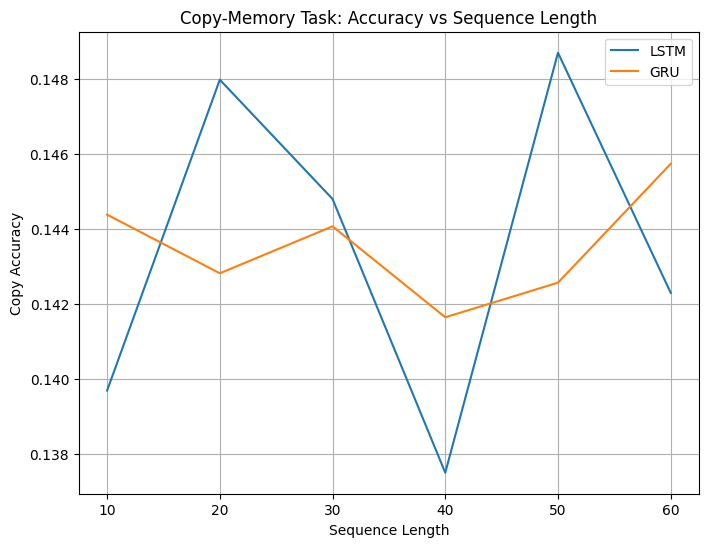

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Reuse the implemented GRU and LSTM (PyTorch), and SimpleSSM above

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def generate_copy_memory_data(seq_len, batch_size, input_size=8, delay=10):
    """Generate a batch for the copy-memory task.
    Each item: input is [seq][0]*delay[seq] and target is [0]*seq_len+delay[seq]
    """
    seq = torch.randint(1, input_size, (batch_size, seq_len))  # (batch, seq_len)
    inp = torch.zeros(batch_size, seq_len + delay + seq_len, input_size)
    tar = torch.zeros(batch_size, seq_len + delay + seq_len, dtype=torch.long)

    # Fill in the initial input sequence
    for b in range(batch_size):
        for t in range(seq_len):
            inp[b, t, seq[b, t]] = 1  # one-hot
            tar[b, seq_len+delay+t] = seq[b, t]

    # Markers can be used if needed - here we just set input as the sequence, then zeros, then expect output
    return inp, tar

def evaluate_model_accuracy(model, seq_lens, num_trials=100, model_type='lstm'):
    accs = []
    input_size = 8
    batch_size = 32

    for seq_len in seq_lens:
        correct = 0
        total = 0
        delay = 10
        for _ in range(num_trials):
            x, y = generate_copy_memory_data(seq_len, batch_size, input_size, delay)
            x = x.to(device)
            y = y.to(device)
            with torch.no_grad():
                if model_type == 'lstm':
                    output, _ = model(x)
                elif model_type == 'gru':
                    output, _ = model(x)
                elif model_type == 'ssm':
                    output = model(x)
                else:
                    raise ValueError("Unknown model_type")

            # Score only the relevant output (final seq_len timesteps)
            out_logits = output[:, -(seq_len):, :]
            pred = out_logits.argmax(dim=-1)
            tgt = y[:, -(seq_len):]
            correct += (pred == tgt).float().sum().item()
            total += tgt.numel()
        accs.append(correct / total)
    return accs

# Wrapper for PyTorch's nn.LSTM to match input/output format
class LSTMWrapper(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, num_layers=num_layers)
        self.linear = nn.Linear(hidden_size, input_size)
    def forward(self, x):
        y, _ = self.lstm(x)
        y = self.linear(y)
        return y, _

# Wrapper for PyTorch's nn.GRU to match input/output format
class GRUWrapper(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True, num_layers=num_layers)
        self.linear = nn.Linear(hidden_size, input_size)
    def forward(self, x):
        y, _ = self.gru(x)
        y = self.linear(y)
        return y, _


# For SSM, wrap the output projection
class SSMFullModel(nn.Module):
    def __init__(self, ssm, out_proj):
        super().__init__()
        self.ssm = ssm
        self.out_proj = out_proj
    def forward(self, x):
        y = self.ssm(x)
        y = self.out_proj(y)
        return y, None
    

input_size = 8
hidden_size = 64
num_layers = 1

lstm_model = LSTMWrapper(input_size, hidden_size, num_layers).to(device)
gru_model = GRUWrapper(input_size, hidden_size, num_layers).to(device)
ssm_model = SimpleSSM(input_size, hidden_size).to(device)
ssm_out_proj = nn.Linear(hidden_size, input_size).to(device)
ssm_full = SSMFullModel(ssm_model, ssm_out_proj).to(device)

# Train function
def train(model, out_proj, model_type, epochs=10, lr=0.01, seq_len=20):
    optimizer = optim.Adam(list(model.parameters()) + (list(out_proj.parameters()) if out_proj else []), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    input_size = 8
    delay = 10
    batch_size = 64
    for epoch in range(epochs):
        x, y = generate_copy_memory_data(seq_len, batch_size, input_size, delay)
        x = x.to(device)
        y = y.to(device)
        logits, _ = model(x)
        loss = loss_fn(logits[:, -(seq_len):, :].reshape(-1, input_size), y[:, -(seq_len):].reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

train_seq_len = 100
lstm_model = train(lstm_model, None, 'lstm', epochs=10, seq_len=train_seq_len)
gru_model = train(gru_model, None, 'gru', epochs=10, seq_len=train_seq_len)
# ssm_model = train(ssm_full, ssm_out_proj, 'ssm', epochs=10, seq_len=train_seq_len)

# Now evaluate for various sequence lengths
seq_lens = list(range(10, 61, 10))
lstm_acc = []
gru_acc = []
ssm_acc = []




lstm_acc = evaluate_model_accuracy(lstm_model, seq_lens, num_trials=10, model_type='lstm')
gru_acc = evaluate_model_accuracy(gru_model, seq_lens, num_trials=10, model_type='gru')
# ssm_acc = evaluate_model_accuracy(ssm_full, seq_lens, num_trials=10, model_type='ssm')

# Plot
plt.figure(figsize=(8, 6))
plt.plot(seq_lens, lstm_acc, label='LSTM')
plt.plot(seq_lens, gru_acc, label='GRU')
# plt.plot(seq_lens, ssm_acc, label='SSM')
plt.xlabel('Sequence Length')
plt.ylabel('Copy Accuracy')
plt.title('Copy-Memory Task: Accuracy vs Sequence Length')
plt.legend()
plt.grid()
plt.show()